In [1]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions

In [2]:
# Generate some sample data
df = pd.DataFrame({
    "X1": [1, 2, 3, 4, 5, 6, 6, 7, 9, 9],
    "X2": [5, 3, 6, 8, 1, 9, 5, 8, 9, 2],
    "Label": [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]
})

In [3]:
df

,X1,X2,Label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

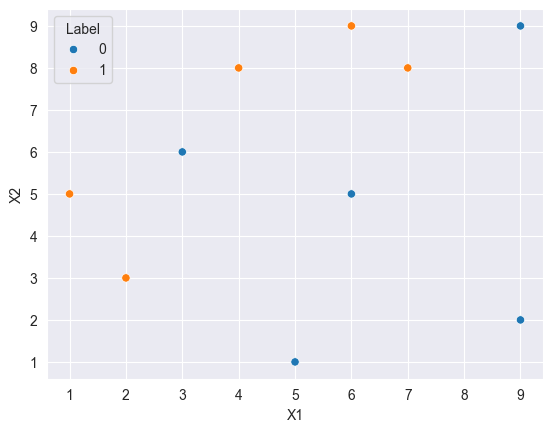

In [4]:
# Visualize the data
import seaborn as sns
sns.scatterplot(x=df["X1"], y=df["X2"], hue=df["Label"])

In [5]:
# Assigning equal weights to each row
df["weights"] = 1/df.shape[0]
df

,X1,X2,Label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [6]:
from sklearn.tree import DecisionTreeClassifier

In [7]:
# Creating a Decision Stump
dt1 = DecisionTreeClassifier(max_depth=1)

In [8]:
# Extracting X and Y
X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

In [9]:
# Train 1st model
dt1.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

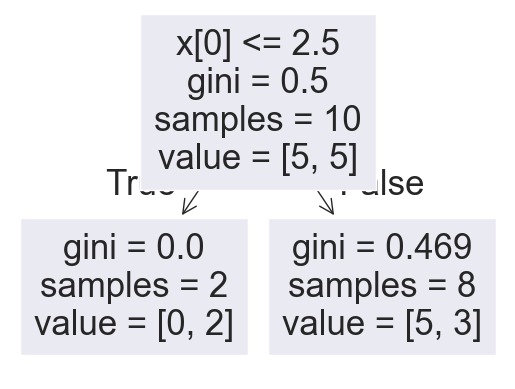

In [10]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

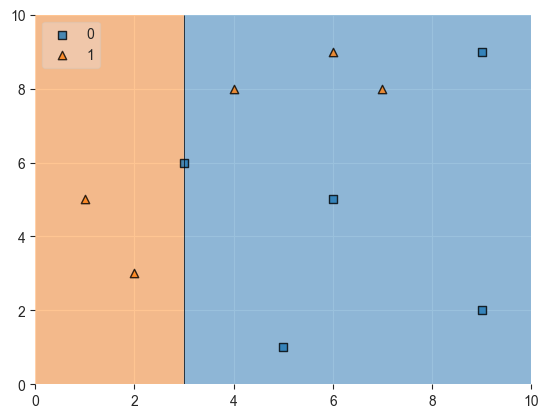

In [11]:
# Decision Boundary
plot_decision_regions(X, y, clf=dt1, legend=2)

In [12]:
# Getting predictions on the training data
df["y_pred"] = dt1.predict(X)
df

,X1,X2,Label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [13]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/error)

In [14]:
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [15]:
# Update weights
def update_weights(row, alpha=0.4236):
  if row["Label"] == row["y_pred"]:
    return row["weights"] * np.exp(-alpha)
  else:
    return row["weights"] * np.exp(alpha)

In [16]:
df["updated_weights"] = df.apply(update_weights, axis=1)
df

,X1,X2,Label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065469
1,2,3,1,0.1,1,0.065469
2,3,6,0,0.1,0,0.065469
3,4,8,1,0.1,0,0.152745
4,5,1,0,0.1,0,0.065469
5,6,9,1,0.1,0,0.152745
6,6,5,0,0.1,0,0.065469
7,7,8,1,0.1,0,0.152745
8,9,9,0,0.1,0,0.065469
9,9,2,0,0.1,0,0.065469


In [17]:
# The sum of updated weights is not 1
df["updated_weights"].sum()

np.float64(0.9165151400883117)

In [18]:
# So we have to normalize it
df["Normalized Weights"] = df["updated_weights"] / df["updated_weights"].sum()
df

,X1,X2,Label,weights,y_pred,updated_weights,Normalized Weights
0,1,5,1,0.1,1,0.065469,0.071432
1,2,3,1,0.1,1,0.065469,0.071432
2,3,6,0,0.1,0,0.065469,0.071432
3,4,8,1,0.1,0,0.152745,0.166659
4,5,1,0,0.1,0,0.065469,0.071432
5,6,9,1,0.1,0,0.152745,0.166659
6,6,5,0,0.1,0,0.065469,0.071432
7,7,8,1,0.1,0,0.152745,0.166659
8,9,9,0,0.1,0,0.065469,0.071432
9,9,2,0,0.1,0,0.065469,0.071432


In [19]:
# Now the sum is equal to 1
df["Normalized Weights"].sum()

np.float64(1.0)

# Creating a range

In [20]:
df["cumsum_upper"] = np.cumsum(df["Normalized Weights"])
df["cumsum_lower"] = np.cumsum(df["Normalized Weights"]) - df["Normalized Weights"]

In [21]:
df[['X1','X2','Label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,Label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065469,0.000000,0.071432
1,2,3,1,0.1,1,0.065469,0.071432,0.142864
2,3,6,0,0.1,0,0.065469,0.142864,0.214296
3,4,8,1,0.1,0,0.152745,0.214296,0.380955
4,5,1,0,0.1,0,0.065469,0.380955,0.452387
5,6,9,1,0.1,0,0.152745,0.452387,0.619045
6,6,5,0,0.1,0,0.065469,0.619045,0.690477
7,7,8,1,0.1,0,0.152745,0.690477,0.857136
8,9,9,0,0.1,0,0.065469,0.857136,0.928568
9,9,2,0,0.1,0,0.065469,0.928568,1.000000


In [22]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [23]:
index_values = create_new_dataset(df)
index_values

[9, 0, 9, 1, 3, 6, 5, 5, 9, 7]

In [24]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [25]:
second_df

,X1,X2,Label,weights
9,9,2,0,0.1
0,1,5,1,0.1
9,9,2,0,0.1
1,2,3,1,0.1
3,4,8,1,0.1
6,6,5,0,0.1
5,6,9,1,0.1
5,6,9,1,0.1
9,9,2,0,0.1
7,7,8,1,0.1


In [ ]:
from sklearn.preprocessing import StandardScaler